# S5 Contrastive SSL Colab

This notebook builds a Colab-friendly S5 self-supervised learning baseline on Utah-array cache shards stored in Google Drive.

It supports two contrastive objectives behind one switch:

- `future_infonce`: CPC-style future-state InfoNCE over S5 hidden states.
- `augment_infonce`: same-window augmentation contrastive learning over pooled segment embeddings.

The notebook keeps the existing `s5_future_prediction.ipynb` data-loading pattern:

- mount Google Drive
- clone the public repo
- copy cache data to `/content`
- train from local disk
- save logs, checkpoints, and plots back to Drive


In [1]:
# Mount Drive and resolve cache / output roots.
from google.colab import drive
from pathlib import Path


drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive")
cache_candidates = [
    DRIVE_ROOT / "utah_ssl" / "data" / "cache_v1",
]

CACHE_ROOT = next((p for p in cache_candidates if p.exists()), cache_candidates[0])
OUTPUT_ROOT = DRIVE_ROOT / "utah_ssl" / "outputs" / "ssl_experiments" / "contrastive"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("DRIVE_ROOT :", DRIVE_ROOT)
print("CACHE_ROOT :", CACHE_ROOT, "| exists:", CACHE_ROOT.exists())
print("OUTPUT_ROOT:", OUTPUT_ROOT, "| exists:", OUTPUT_ROOT.exists())

if CACHE_ROOT.exists():
    datasets = sorted(p.name for p in CACHE_ROOT.iterdir() if p.is_dir())
    print("datasets:", datasets)
else:
    print("cache candidates checked:")
    for path in cache_candidates:
        print(" -", path)


Mounted at /content/drive
DRIVE_ROOT : /content/drive/MyDrive
CACHE_ROOT : /content/drive/MyDrive/utah_ssl/data/cache_v1 | exists: True
OUTPUT_ROOT: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive | exists: True
datasets: ['000950', 'brain2text24', 'brain2text25', 'motor_data', 'plug_n_play', 'unsupervised_cursor_recalibration_offline', 'unsupervised_cursor_recalibration_online', 'willett_handwriting']


In [2]:
# Clone the public repo and import the reusable contrastive SSL helpers.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/ethan-read/utah-ssl.git"
REPO_DIR = Path("/content/utah-ssl")
EXPERIMENTS_DIR = REPO_DIR / "analysis" / "active" / "ssl_experiments"
CONTRASTIVE_SSL_DIR = EXPERIMENTS_DIR / "contrastive_ssl"
SSL_DIR = REPO_DIR / "analysis" / "active" / "transfer_benchmark" / "ssl_autoresearch"

os.chdir("/content")

if REPO_DIR.exists():
    print("Using existing repo:", REPO_DIR)
else:
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

os.chdir(REPO_DIR)

for candidate in (REPO_DIR, EXPERIMENTS_DIR, SSL_DIR):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

os.environ["SSL_AUTORESEARCH_CACHE_ROOT"] = str(CACHE_ROOT)
os.environ["SSL_AUTORESEARCH_OUTPUT_ROOT"] = str(OUTPUT_ROOT)

if not CONTRASTIVE_SSL_DIR.exists():
    raise FileNotFoundError(
        "The cloned repo does not contain analysis/active/ssl_experiments/contrastive_ssl. "
        "If you are running this notebook from Colab, make sure REPO_DIR points at a repo checkout that includes the refactor."
    )

from contrastive_ssl import (
    CacheAccessConfig,
    DownstreamProbeConfig,
    SSLTrainingConfig,
    build_random_init_probe_state,
    build_segment_sampler,
    list_ssl_checkpoints,
    load_precomputed_session_feature_stats_into_cache_context,
    plot_ssl_training_history,
    prepare_cache_context,
    recover_downstream_probe_state,
    recover_ssl_run_state_from_checkpoint,
    resolve_ssl_checkpoint_path,
    run_downstream_probe,
    run_probe_head_sweep,
    run_ssl_training,
)

print("cwd:", Path.cwd())
print("repo dir exists:", REPO_DIR.exists(), REPO_DIR)
print("experiments dir exists:", EXPERIMENTS_DIR.exists(), EXPERIMENTS_DIR)
print("contrastive_ssl dir exists:", CONTRASTIVE_SSL_DIR.exists(), CONTRASTIVE_SSL_DIR)
print("ssl dir exists:", SSL_DIR.exists(), SSL_DIR)
print("SSL_AUTORESEARCH_CACHE_ROOT:", os.environ["SSL_AUTORESEARCH_CACHE_ROOT"])
print("SSL_AUTORESEARCH_OUTPUT_ROOT:", os.environ["SSL_AUTORESEARCH_OUTPUT_ROOT"])


cwd: /content/utah-ssl
repo dir exists: True /content/utah-ssl
experiments dir exists: True /content/utah-ssl/analysis/active/ssl_experiments
contrastive_ssl dir exists: True /content/utah-ssl/analysis/active/ssl_experiments/contrastive_ssl
ssl dir exists: True /content/utah-ssl/analysis/active/transfer_benchmark/ssl_autoresearch
SSL_AUTORESEARCH_CACHE_ROOT: /content/drive/MyDrive/utah_ssl/data/cache_v1
SSL_AUTORESEARCH_OUTPUT_ROOT: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive


In [37]:
# Experiment config.
# Update the workflow switches here before running the cells below.
SEED = 7

# Used by the "Acquire SSL State" cell.
SSL_STATE_MODE = "train"  # Set to "recover" to load a previous checkpoint for analysis/probes.
# Used by the "Load precomputed SSL session stats" cell.
STABLE_SSL_SESSION_STATS_PATH = (
    DRIVE_ROOT
    / "utah_ssl"
    / "outputs"
    / "ssl_experiments"
    / "contrastive"
    / "precomputed_ssl_session_stats"
    / "session_feature_stats_session_featurewise_v1_refds000950_cap126682_tx256_sbp256_stable.pt"
)
# Used only when SSL_STATE_MODE == "recover" in the "Acquire SSL State" cell.
SSL_RECOVERY_EXPLICIT_CHECKPOINT_PATH = None
SSL_RECOVERY_RUN_DIR = None
# Optional: used by downstream recovery and the SSL retrieval diagnostic cells after SSL state is acquired.
ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH = None

OBJECTIVE_MODE = "future_infonce"
SEGMENT_BINS = 64
# With patch_size=4 and stride=2, horizon=6 starts the target patch strictly after the current patch.
FUTURE_HORIZONS = (8, 12)
PATCH_SIZE = 4
PATCH_STRIDE = 2
HIDDEN_SIZE = 256
S5_STATE_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.1
BATCH_SIZE = 32
NUM_STEPS = 600
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-2
TEMPERATURE = 0.1
VAL_EVERY = 50
VAL_BATCHES = 10
CHECKPOINT_EVERY_STEPS = 100
DATASET_WEIGHT_ALPHA = 0.25
EXAMPLES_PER_SHARD = 8
POST_PROJ_NORM = "rms"
BACKBONE_DIRECTION = "causal"
# CACHE_ACCESS_MODE = "copy_to_local"
CACHE_ACCESS_MODE = "drive_direct"

LOCAL_CACHE_BASE = "/content/utah_ssl_cache"
FORCE_RECOPY_LOCAL_CACHE = False
EXCLUDED_DATASETS = {"brain2text25"}
LOG_EVERY = 10
# Use a cheap cache-context normalization during setup, then swap in precomputed SSL session z-scoring below.
NORMALIZE_IMPL_VERSION = "session_featurewise_v1"
CACHE_PREPARE_NORMALIZE_IMPL_VERSION = "segment_prefix_v1"
NORMALIZE_CONTEXT_BINS = min(16, SEGMENT_BINS)  # Used only by the segment_prefix_v1 fallback.

AUGMENT_CFG = {
    "noise_std": 0.01,
    "scale_jitter": 0.05,
    "offset_jitter": 0.05,
    "time_mask_frac": 0.10,
    "channel_dropout_prob": 0.05,
    "clip_value": 20.0,
}

CACHE_ACCESS_CONFIG = CacheAccessConfig(
    mode=CACHE_ACCESS_MODE,
    local_cache_base=LOCAL_CACHE_BASE,
    force_recopy_local_cache=FORCE_RECOPY_LOCAL_CACHE,
    excluded_datasets=tuple(sorted(EXCLUDED_DATASETS)),
    seed=SEED,
    segment_bins=SEGMENT_BINS,
    normalize_context_bins=NORMALIZE_CONTEXT_BINS,
    normalize_impl_version=CACHE_PREPARE_NORMALIZE_IMPL_VERSION,
    examples_per_shard=EXAMPLES_PER_SHARD,
)
SSL_TRAINING_CONFIG = SSLTrainingConfig(
    seed=SEED,
    objective_mode=OBJECTIVE_MODE,
    segment_bins=SEGMENT_BINS,
    future_horizons=FUTURE_HORIZONS,
    patch_size=PATCH_SIZE,
    patch_stride=PATCH_STRIDE,
    hidden_size=HIDDEN_SIZE,
    s5_state_size=S5_STATE_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    batch_size=BATCH_SIZE,
    num_steps=NUM_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    temperature=TEMPERATURE,
    val_every=VAL_EVERY,
    val_batches=VAL_BATCHES,
    checkpoint_every_steps=CHECKPOINT_EVERY_STEPS,
    dataset_weight_alpha=DATASET_WEIGHT_ALPHA,
    examples_per_shard=EXAMPLES_PER_SHARD,
    log_every=LOG_EVERY,
    post_proj_norm=POST_PROJ_NORM,
    backbone_direction=BACKBONE_DIRECTION,
    augment_cfg=dict(AUGMENT_CFG),
)

print("Notebook workflow switches:", {
    "SSL_STATE_MODE": SSL_STATE_MODE,
    "STABLE_SSL_SESSION_STATS_PATH": STABLE_SSL_SESSION_STATS_PATH,
    "SSL_RECOVERY_EXPLICIT_CHECKPOINT_PATH": SSL_RECOVERY_EXPLICIT_CHECKPOINT_PATH,
    "SSL_RECOVERY_RUN_DIR": SSL_RECOVERY_RUN_DIR,
    "ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH": ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH,
})
print("SSL patch config:", {
    "patch_size": PATCH_SIZE,
    "patch_stride": PATCH_STRIDE,
    "future_horizons": FUTURE_HORIZONS,
})
print("SSL checkpoint cadence:", CHECKPOINT_EVERY_STEPS)
print("SSL normalization config:", {
    "ssl_normalize_impl_version": NORMALIZE_IMPL_VERSION,
    "prepare_cache_normalize_impl_version": CACHE_PREPARE_NORMALIZE_IMPL_VERSION,
    "normalize_context_bins_fallback": NORMALIZE_CONTEXT_BINS,
})
print("CACHE_ACCESS_CONFIG:", CACHE_ACCESS_CONFIG)
print("SSL_TRAINING_CONFIG:", SSL_TRAINING_CONFIG)


Notebook workflow switches: {'SSL_STATE_MODE': 'train', 'STABLE_SSL_SESSION_STATS_PATH': PosixPath('/content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/precomputed_ssl_session_stats/session_feature_stats_session_featurewise_v1_refds000950_cap126682_tx256_sbp256_stable.pt'), 'SSL_RECOVERY_EXPLICIT_CHECKPOINT_PATH': None, 'SSL_RECOVERY_RUN_DIR': None, 'ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH': None}
SSL patch config: {'patch_size': 4, 'patch_stride': 2, 'future_horizons': (8, 12)}
SSL checkpoint cadence: 100
SSL normalization config: {'ssl_normalize_impl_version': 'session_featurewise_v1', 'prepare_cache_normalize_impl_version': 'segment_prefix_v1', 'normalize_context_bins_fallback': 16}
CACHE_ACCESS_CONFIG: CacheAccessConfig(mode='drive_direct', local_cache_base='/content/utah_ssl_cache', force_recopy_local_cache=False, excluded_datasets=('brain2text25',), seed=7, segment_bins=64, normalize_context_bins=16, normalize_impl_version='segment_prefix_v1', examples_per_shard=8, tx

In [38]:
# Resolve cache access mode, summarize datasets, and build the reusable cache context.
import os

CACHE_CONTEXT = prepare_cache_context(
    cache_candidates=cache_candidates,
    config=CACHE_ACCESS_CONFIG,
)

DRIVE_CACHE_ROOT = CACHE_CONTEXT.drive_cache_root
CACHE_ROOT = CACHE_CONTEXT.cache_root
ACTIVE_CACHE_ROOT = CACHE_CONTEXT.cache_root
CACHE_COPY_USED = CACHE_CONTEXT.cache_copy_used
SOURCE_CACHE_SIGNATURE = CACHE_CONTEXT.source_cache_signature
available_datasets = CACHE_CONTEXT.available_datasets
pretrain_datasets = CACHE_CONTEXT.pretrain_datasets
session_split_summary = CACHE_CONTEXT.session_split_summary
SHARD_STORE = CACHE_CONTEXT.shard_store
SHARD_CACHE_RAM_GB = SHARD_STORE.summary()["budget_gb"]
HAS_VAL_DATASETS = CACHE_CONTEXT.has_val_datasets
TX_DIM = CACHE_CONTEXT.tx_dim
SBP_DIM = CACHE_CONTEXT.sbp_dim
FULL_DIM = CACHE_CONTEXT.full_dim
CACHE_CONTEXT_NORMALIZE_IMPL_VERSION = CACHE_CONTEXT.normalize_impl_version
NORMALIZE_CONTEXT_BINS = CACHE_CONTEXT.normalize_context_bins
SSL_SESSION_STATS_COUNT = len(CACHE_CONTEXT.session_feature_stats)

os.environ["SSL_AUTORESEARCH_CACHE_ROOT"] = str(CACHE_ROOT)

print("CACHE_ACCESS_MODE:", CACHE_ACCESS_CONFIG.mode)
print("CACHE_COPY_USED:", CACHE_COPY_USED)
print("ACTIVE_CACHE_ROOT:", CACHE_ROOT)
print("CACHE_CONTEXT_NORMALIZE_IMPL_VERSION (before SSL stats load):", CACHE_CONTEXT_NORMALIZE_IMPL_VERSION)
print("TARGET_SSL_NORMALIZE_IMPL_VERSION:", NORMALIZE_IMPL_VERSION)
print("NORMALIZE_CONTEXT_BINS (fallback only):", NORMALIZE_CONTEXT_BINS)
print("SSL_SESSION_STATS_COUNT:", SSL_SESSION_STATS_COUNT)
print("SHARD_CACHE_RAM_GB:", SHARD_CACHE_RAM_GB)
print("available datasets:")
for name in available_datasets:
    tag = "excluded" if name in EXCLUDED_DATASETS else "included"
    print(f" - {name} [{tag}]")
print("session split summary:")
for dataset in pretrain_datasets:
    summary = session_split_summary[dataset]
    print(
        f" - {dataset}: sessions={summary['total_sessions']} train_sessions={summary['train_sessions']} "
        f"val_sessions={summary['val_sessions']} train_examples={summary['train_examples']} "
        f"val_examples={summary['val_examples']} val_eligible={summary['val_eligible']}"
    )
print("shard cache:", SHARD_STORE.summary())


using Drive-backed cache directly; skipping local copy
source: /content/drive/MyDrive/utah_ssl/data/cache_v1
source signature: 9cdbfaa6cf55
CACHE_ACCESS_MODE: drive_direct
CACHE_COPY_USED: False
ACTIVE_CACHE_ROOT: /content/drive/MyDrive/utah_ssl/data/cache_v1
CACHE_CONTEXT_NORMALIZE_IMPL_VERSION (before SSL stats load): segment_prefix_v1
TARGET_SSL_NORMALIZE_IMPL_VERSION: session_featurewise_v1
NORMALIZE_CONTEXT_BINS (fallback only): 16
SSL_SESSION_STATS_COUNT: 0
SHARD_CACHE_RAM_GB: 8.0
available datasets:
 - 000950 [included]
 - brain2text24 [included]
 - brain2text25 [excluded]
 - motor_data [included]
 - plug_n_play [included]
 - unsupervised_cursor_recalibration_offline [included]
 - unsupervised_cursor_recalibration_online [included]
 - willett_handwriting [included]
session split summary:
 - 000950: sessions=47 train_sessions=37 val_sessions=10 train_examples=569 val_examples=159 val_eligible=True
 - brain2text24: sessions=28 train_sessions=22 val_sessions=6 train_examples=12811 

In [39]:
# Load precomputed SSL session-level featurewise z-scoring stats from the stable Drive path.
# Controlled by STABLE_SSL_SESSION_STATS_PATH in the top config cell.
SSL_SESSION_STATS_STATE = load_precomputed_session_feature_stats_into_cache_context(
    cache_context=CACHE_CONTEXT,
    stats_path=STABLE_SSL_SESSION_STATS_PATH,
    normalize_impl_version=NORMALIZE_IMPL_VERSION,
)
SSL_SESSION_STATS_PATH = Path(SSL_SESSION_STATS_STATE["stats_path"])
SSL_SESSION_STATS_METADATA = dict(SSL_SESSION_STATS_STATE["metadata"])
SSL_SESSION_FEATURE_STATS = dict(SSL_SESSION_STATS_STATE["session_feature_stats"])
CACHE_CONTEXT_NORMALIZE_IMPL_VERSION = CACHE_CONTEXT.normalize_impl_version
SSL_SESSION_STATS_COUNT = int(SSL_SESSION_STATS_STATE["session_count"])

print("Loaded cached SSL session stats from stable path.")
print("SSL_SESSION_STATS_PATH:", SSL_SESSION_STATS_PATH)
print("CACHE_CONTEXT_NORMALIZE_IMPL_VERSION:", CACHE_CONTEXT_NORMALIZE_IMPL_VERSION)
print("SSL_SESSION_STATS_COUNT:", SSL_SESSION_STATS_COUNT)
print(
    "SSL session stats metadata:",
    {
        "reference_dataset": SSL_SESSION_STATS_METADATA.get("reference_dataset"),
        "reference_session_key": SSL_SESSION_STATS_METADATA.get("reference_session_key"),
        "reference_session_bins": SSL_SESSION_STATS_METADATA.get("reference_session_bins"),
        "session_stats_cap_bins": SSL_SESSION_STATS_METADATA.get("session_stats_cap_bins"),
        "truncated_sessions": SSL_SESSION_STATS_METADATA.get("truncated_sessions"),
    },
)


Loaded cached SSL session stats from stable path.
SSL_SESSION_STATS_PATH: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/precomputed_ssl_session_stats/session_feature_stats_session_featurewise_v1_refds000950_cap126682_tx256_sbp256_stable.pt
CACHE_CONTEXT_NORMALIZE_IMPL_VERSION: session_featurewise_v1
SSL_SESSION_STATS_COUNT: 251
SSL session stats metadata: {'reference_dataset': '000950', 'reference_session_key': '000950:sub-T5-held-in-calib_ses-20220518', 'reference_session_bins': 63341, 'session_stats_cap_bins': 126682, 'truncated_sessions': 70}


In [40]:
# Optional: sampler smoke test.
from collections import Counter

INSPECT_BATCH_SIZE = 8
inspect_train_sampler = build_segment_sampler(
    CACHE_CONTEXT,
    "train",
    batch_size=INSPECT_BATCH_SIZE,
    seed=SEED,
    segment_bins=SEGMENT_BINS,
    dataset_weight_alpha=DATASET_WEIGHT_ALPHA,
    examples_per_shard=EXAMPLES_PER_SHARD,
)
inspect_batch = inspect_train_sampler.sample_batch()

print("train batch shapes:")
print(" - x           :", tuple(inspect_batch["x"].shape))
print(" - feature_mask:", tuple(inspect_batch["feature_mask"].shape))
print(" - lengths     :", tuple(inspect_batch["lengths"].shape))
print(" - dataset mix :", Counter(inspect_batch["datasets"]))
print(" - session keys:", inspect_batch["session_keys"][:3])

if HAS_VAL_DATASETS:
    inspect_val_sampler = build_segment_sampler(
        CACHE_CONTEXT,
        "val",
        batch_size=min(INSPECT_BATCH_SIZE, 4),
        seed=SEED + 1,
        segment_bins=SEGMENT_BINS,
        dataset_weight_alpha=DATASET_WEIGHT_ALPHA,
        examples_per_shard=EXAMPLES_PER_SHARD,
    )
    inspect_val_batch = inspect_val_sampler.sample_batch()
    print("\nval batch shapes:")
    print(" - x           :", tuple(inspect_val_batch["x"].shape))
    print(" - feature_mask:", tuple(inspect_val_batch["feature_mask"].shape))
    print(" - lengths     :", tuple(inspect_val_batch["lengths"].shape))
    print(" - dataset mix :", Counter(inspect_val_batch["datasets"]))
else:
    print("\nNo validation sampler was built because all datasets are single-session.")


train batch shapes:
 - x           : (8, 64, 512)
 - feature_mask: (8, 512)
 - lengths     : (8,)
 - dataset mix : Counter({'willett_handwriting': 2, 'unsupervised_cursor_recalibration_online': 2, '000950': 1, 'unsupervised_cursor_recalibration_offline': 1, 'motor_data': 1, 'brain2text24': 1})
 - session keys: ['000950:sub-T5-held-in-calib_ses-20220525', 'unsupervised_cursor_recalibration_offline:t5.2019.04.01', 'willett_handwriting:t5.2019.05.08']

val batch shapes:
 - x           : (4, 64, 512)
 - feature_mask: (4, 512)
 - lengths     : (4,)
 - dataset mix : Counter({'motor_data': 2, 'willett_handwriting': 1, 'unsupervised_cursor_recalibration_online': 1})


In [41]:
# Optional: runtime summary.
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
print("FULL_DIM:", FULL_DIM)
print("pretrain_datasets:", pretrain_datasets)
print("HAS_VAL_DATASETS:", HAS_VAL_DATASETS)
print("CACHE_CONTEXT_NORMALIZE_IMPL_VERSION:", CACHE_CONTEXT.normalize_impl_version)
print("SSL_SESSION_STATS_COUNT:", len(CACHE_CONTEXT.session_feature_stats))
if "SSL_SESSION_STATS_PATH" in globals():
    print("SSL_SESSION_STATS_PATH:", SSL_SESSION_STATS_PATH)


DEVICE: cuda
FULL_DIM: 512
pretrain_datasets: ['000950', 'brain2text24', 'motor_data', 'plug_n_play', 'unsupervised_cursor_recalibration_offline', 'unsupervised_cursor_recalibration_online', 'willett_handwriting']
HAS_VAL_DATASETS: True
CACHE_CONTEXT_NORMALIZE_IMPL_VERSION: session_featurewise_v1
SSL_SESSION_STATS_COUNT: 251
SSL_SESSION_STATS_PATH: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/precomputed_ssl_session_stats/session_feature_stats_session_featurewise_v1_refds000950_cap126682_tx256_sbp256_stable.pt


In [42]:
# Acquire SSL state for the rest of the notebook.
# Controlled by SSL_STATE_MODE, SSL_RECOVERY_EXPLICIT_CHECKPOINT_PATH, SSL_RECOVERY_RUN_DIR,
# and ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH in the top config cell.
if NORMALIZE_IMPL_VERSION == "session_featurewise_v1" and not CACHE_CONTEXT.session_feature_stats:
    raise RuntimeError("Run the stable SSL session stats cell first so session-level z-scoring is loaded into CACHE_CONTEXT.")

if SSL_STATE_MODE == "train":
    SSL_RUN_STATE = run_ssl_training(
        cache_context=CACHE_CONTEXT,
        config=SSL_TRAINING_CONFIG,
        output_root=OUTPUT_ROOT,
        device=DEVICE,
    )
elif SSL_STATE_MODE == "recover":
    RECOVERED_SSL_CHECKPOINT_PATH = resolve_ssl_checkpoint_path(
        output_root=OUTPUT_ROOT,
        explicit_checkpoint_path=SSL_RECOVERY_EXPLICIT_CHECKPOINT_PATH,
        run_dir=SSL_RECOVERY_RUN_DIR,
    )
    SSL_RUN_STATE = recover_ssl_run_state_from_checkpoint(
        checkpoint_path=RECOVERED_SSL_CHECKPOINT_PATH,
        cache_context=CACHE_CONTEXT,
        device=DEVICE,
        fallback_config=SSL_TRAINING_CONFIG,
    )
else:
    raise ValueError(f"Unsupported SSL_STATE_MODE: {SSL_STATE_MODE}")

if ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH is None:
    ACTIVE_SSL_CHECKPOINT_PATH = Path(SSL_RUN_STATE["checkpoint_path"])
else:
    ACTIVE_SSL_CHECKPOINT_PATH = Path(ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH)
    if not ACTIVE_SSL_CHECKPOINT_PATH.exists():
        raise FileNotFoundError(
            f"ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH does not exist: {ACTIVE_SSL_CHECKPOINT_PATH}"
        )
ACTIVE_SSL_CHECKPOINT_RUN_DIR = (
    ACTIVE_SSL_CHECKPOINT_PATH.parent.parent
    if ACTIVE_SSL_CHECKPOINT_PATH.parent.name == "checkpoints"
    else ACTIVE_SSL_CHECKPOINT_PATH.parent
)

# Backward-compatible globals for downstream cells.
model = SSL_RUN_STATE["model"]
optimizer = SSL_RUN_STATE["optimizer"]
TRAIN_SAMPLER = SSL_RUN_STATE["train_sampler"]
VAL_SAMPLER = SSL_RUN_STATE["val_sampler"]
run_name = SSL_RUN_STATE["run_name"]
run_dir = SSL_RUN_STATE["run_dir"]
progress_path = SSL_RUN_STATE["progress_path"]
checkpoint_path = SSL_RUN_STATE["checkpoint_path"]
checkpoints_dir = SSL_RUN_STATE["checkpoints_dir"]
plot_loss_path = SSL_RUN_STATE["plot_loss_path"]
plot_top1_path = SSL_RUN_STATE["plot_top1_path"]
config = SSL_RUN_STATE["config"]
best_score = SSL_RUN_STATE["best_score"]
best_step = SSL_RUN_STATE["best_step"]
train_history = SSL_RUN_STATE["train_history"]
val_history = SSL_RUN_STATE["val_history"]

print("SSL_STATE_MODE:", SSL_STATE_MODE)
print("SSL_RUN_STATE ready:", run_dir)
print("SSL_RUN_STATE checkpoint:", checkpoint_path)
print("SSL step checkpoints dir:", checkpoints_dir)
print("SSL best step:", best_step)
if SSL_STATE_MODE == "recover":
    print("Recovered checkpoint kind:", SSL_RUN_STATE.get("checkpoint_kind"))
    print("Recovered checkpoint step:", SSL_RUN_STATE.get("checkpoint_step"))
print("ACTIVE_SSL_CHECKPOINT_PATH:", ACTIVE_SSL_CHECKPOINT_PATH)
print("ACTIVE_SSL_CHECKPOINT_RUN_DIR:", ACTIVE_SSL_CHECKPOINT_RUN_DIR)
if ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH is not None:
    print("ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH:", ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH)


step=001 train_loss=6.6300 train_top1=0.0030 grad_norm=2.1459 sample_s=0.52 model_s=0.10
step=010 train_loss=6.4924 train_top1=0.0022 grad_norm=2.0303 sample_s=0.26 model_s=0.10
step=020 train_loss=6.2449 train_top1=0.0063 grad_norm=2.1233 sample_s=0.23 model_s=0.09
step=030 train_loss=5.9172 train_top1=0.0167 grad_norm=2.3764 sample_s=0.04 model_s=0.09
step=040 train_loss=5.5250 train_top1=0.0175 grad_norm=2.1738 sample_s=0.41 model_s=0.09
step=050 train_loss=5.4346 train_top1=0.0197 grad_norm=2.4612 sample_s=0.04 model_s=0.09
step=050 val_loss=5.3103 val_top1=0.0213 positive_pairs=13440
step=060 train_loss=4.8758 train_top1=0.0495 grad_norm=2.4093 sample_s=0.19 model_s=0.10
step=070 train_loss=4.5238 train_top1=0.0555 grad_norm=2.4186 sample_s=0.17 model_s=0.10
step=080 train_loss=4.3269 train_top1=0.0506 grad_norm=2.3243 sample_s=0.13 model_s=0.10
step=090 train_loss=4.0583 train_top1=0.0767 grad_norm=2.3552 sample_s=0.18 model_s=0.10
step=100 train_loss=3.8037 train_top1=0.0922 gra

In [43]:
# Temporary SSL resume cell: continue training from the current in-memory SSL_RUN_STATE.
import json
import time
from collections import Counter
from pathlib import Path

import torch

from contrastive_ssl.model import sync_device
from contrastive_ssl.objectives import compute_objective_metrics, summarize_metrics
from contrastive_ssl.training import (
    _build_checkpoint_payload,
    _final_checkpoint_filename,
    _step_checkpoint_filename,
    evaluate_model,
)

RESUME_ADDITIONAL_STEPS = 400

model = SSL_RUN_STATE["model"]
optimizer = SSL_RUN_STATE["optimizer"]
train_sampler = SSL_RUN_STATE["train_sampler"]
val_sampler = SSL_RUN_STATE["val_sampler"]

run_dir = Path(SSL_RUN_STATE["run_dir"])
progress_path = Path(SSL_RUN_STATE["progress_path"])
checkpoint_path = Path(SSL_RUN_STATE["checkpoint_path"])
checkpoints_dir = Path(SSL_RUN_STATE["checkpoints_dir"])
checkpoints_dir.mkdir(parents=True, exist_ok=True)

config_payload = dict(SSL_RUN_STATE["config"])
start_step = 0
if train_history:
    start_step = max(int(record["step"]) for record in train_history if record.get("event") == "train")

target_step = start_step + int(RESUME_ADDITIONAL_STEPS)
config_payload["num_steps"] = int(target_step)

train_history = list(SSL_RUN_STATE.get("train_history", []))
val_history = list(SSL_RUN_STATE.get("val_history", []))
dataset_counter = Counter(SSL_RUN_STATE.get("dataset_counts", {}))

best_score = float(SSL_RUN_STATE["best_score"]) if SSL_RUN_STATE.get("best_score") is not None else float("inf")
best_step = int(SSL_RUN_STATE["best_step"]) if SSL_RUN_STATE.get("best_step") is not None else None
best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

print("Continuing in-memory SSL training")
print(" - run_dir:", run_dir)
print(" - start_step:", start_step)
print(" - target_step:", target_step)

resume_start_time = time.time()

for step in range(start_step + 1, target_step + 1):
    model.train()
    optimizer.zero_grad(set_to_none=True)

    sample_start = time.time()
    batch = train_sampler.sample_batch()
    sample_seconds = time.time() - sample_start
    dataset_mix = dict(Counter(batch["datasets"]))
    dataset_counter.update(batch["datasets"])

    sync_device(DEVICE)
    model_start = time.time()
    metrics = compute_objective_metrics(
        model,
        batch,
        objective_mode=str(config_payload["objective_mode"]),
        device=DEVICE,
        temperature=float(config_payload["temperature"]),
        horizons=tuple(config_payload["future_horizons"]),
        augment_cfg=dict(config_payload["augment_cfg"]),
    )
    loss = metrics["loss"]
    loss.backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    sync_device(DEVICE)
    model_seconds = time.time() - model_start

    summary = summarize_metrics(metrics)
    shard_summary = CACHE_CONTEXT.shard_store.summary()
    train_record = {
        "event": "train",
        "step": step,
        "elapsed_seconds": float(time.time() - resume_start_time),
        "sample_seconds": float(sample_seconds),
        "model_seconds": float(model_seconds),
        "grad_norm": float(grad_norm),
        "cached_shards": int(shard_summary["cached_shards"]),
        "cached_gb": float(shard_summary["cached_gb"]),
        "dataset_mix": dataset_mix,
        **summary,
    }
    train_history.append(train_record)
    with progress_path.open("a") as handle:
        handle.write(json.dumps(train_record) + "\n")

    if val_sampler is None and summary["loss"] < best_score:
        best_score = float(summary["loss"])
        best_step = int(step)
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if step == start_step + 1 or step % 10 == 0:
        print(
            f"step={step:04d} train_loss={summary['loss']:.4f} train_top1={summary['top1']:.4f} "
            f"grad_norm={float(grad_norm):.4f} sample_s={sample_seconds:.2f} model_s={model_seconds:.2f}"
        )

    if val_sampler is not None and (
        step % int(config_payload["val_every"]) == 0 or step == int(target_step)
    ):
        val_result = evaluate_model(
            model,
            val_sampler,
            objective_mode=str(config_payload["objective_mode"]),
            num_batches=int(config_payload["val_batches"]),
            device=DEVICE,
            temperature=float(config_payload["temperature"]),
            horizons=tuple(config_payload["future_horizons"]),
            augment_cfg=dict(config_payload["augment_cfg"]),
        )
        val_record = {
            "event": "val",
            "step": step,
            "elapsed_seconds": float(time.time() - resume_start_time),
            **val_result,
        }
        val_history.append(val_record)
        with progress_path.open("a") as handle:
            handle.write(json.dumps(val_record) + "\n")

        print(
            f"step={step:04d} val_loss={val_result['loss']:.4f} val_top1={val_result['top1']:.4f} "
            f"positive_pairs={val_result['positive_pairs']}"
        )

        if val_result["loss"] < best_score:
            best_score = float(val_result["loss"])
            best_step = int(step)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    checkpoint_every = config_payload.get("checkpoint_every_steps")
    if checkpoint_every is not None and step % int(checkpoint_every) == 0:
        step_checkpoint_path = checkpoints_dir / _step_checkpoint_filename(step)
        torch.save(
            _build_checkpoint_payload(
                model=model,
                optimizer=optimizer,
                config_payload=config_payload,
                step=step,
                best_score=best_score,
                best_step=best_step,
                checkpoint_kind="step",
                dataset_counter=dataset_counter,
            ),
            step_checkpoint_path,
        )
        print("saved_step_checkpoint:", step_checkpoint_path)

if best_state is not None:
    model.load_state_dict(best_state)

final_payload = _build_checkpoint_payload(
    model=model,
    optimizer=optimizer,
    config_payload=config_payload,
    step=target_step,
    best_score=best_score,
    best_step=best_step,
    checkpoint_kind="final",
    train_history=train_history,
    val_history=val_history,
    dataset_counter=dataset_counter,
)
torch.save(final_payload, checkpoint_path)

timestamped_final_checkpoint_path = checkpoints_dir / _final_checkpoint_filename(target_step)
torch.save(final_payload, timestamped_final_checkpoint_path)

SSL_RUN_STATE.update({
    "model": model,
    "optimizer": optimizer,
    "train_sampler": train_sampler,
    "val_sampler": val_sampler,
    "config": config_payload,
    "best_score": best_score,
    "best_step": best_step,
    "train_history": train_history,
    "val_history": val_history,
    "dataset_counts": dict(dataset_counter),
    "checkpoint_step": int(target_step),
    "checkpoint_kind": "final",
})

# Refresh globals used later in the notebook
config = SSL_RUN_STATE["config"]
best_score = SSL_RUN_STATE["best_score"]
best_step = SSL_RUN_STATE["best_step"]
train_history = SSL_RUN_STATE["train_history"]
val_history = SSL_RUN_STATE["val_history"]
ACTIVE_SSL_CHECKPOINT_PATH = checkpoint_path
ACTIVE_SSL_CHECKPOINT_RUN_DIR = run_dir

print("Resume complete")
print(" - target_step:", target_step)
print(" - best_score:", best_score)
print(" - best_step:", best_step)
print(" - checkpoint_path:", checkpoint_path)
print(" - timestamped_final_checkpoint_path:", timestamped_final_checkpoint_path)


Continuing in-memory SSL training
 - run_dir: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260411T162353Z
 - start_step: 600
 - target_step: 1000
step=0601 train_loss=2.3288 train_top1=0.1009 grad_norm=0.9597 sample_s=0.22 model_s=0.09
step=0610 train_loss=2.3015 train_top1=0.0954 grad_norm=0.7486 sample_s=0.08 model_s=0.09
step=0620 train_loss=2.3454 train_top1=0.0943 grad_norm=0.9682 sample_s=0.04 model_s=0.10
step=0630 train_loss=2.3633 train_top1=0.0929 grad_norm=0.9273 sample_s=0.18 model_s=0.09
step=0640 train_loss=2.3547 train_top1=0.0907 grad_norm=0.9164 sample_s=0.05 model_s=0.09
step=0650 train_loss=2.3170 train_top1=0.1010 grad_norm=0.8115 sample_s=0.21 model_s=0.09
step=0650 val_loss=2.3185 val_top1=0.0836 positive_pairs=13440
step=0660 train_loss=2.3693 train_top1=0.0867 grad_norm=1.0132 sample_s=0.10 model_s=0.10
step=0670 train_loss=2.3545 train_top1=0.0901 grad_norm=0.8951 sample_s=0.22 model_s=0.09
step=0680 train_

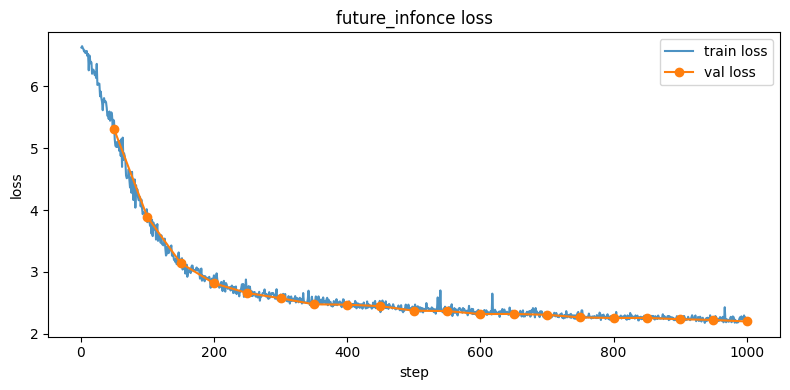

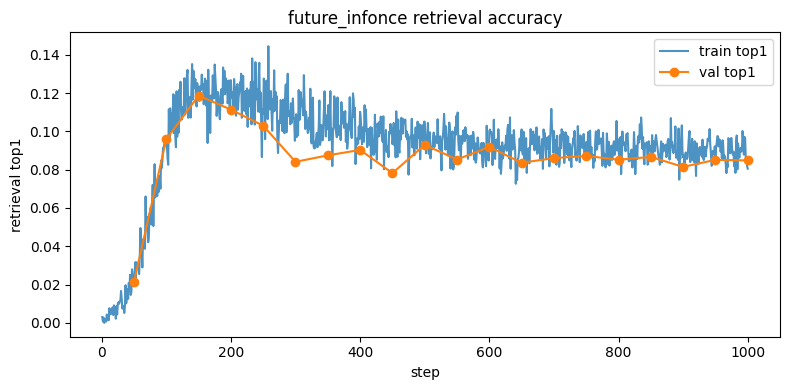

train_start_loss: 6.629961967468262
train_final_loss: 2.2181499004364014
train_best_loss: 2.1737475395202637 at step 937
train_final_top1: 0.08052060008049011
val_best_loss: 2.1965649127960205 at step 1000
val_best_top1: 0.11867134273052216 at step 150
plot_loss_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260411T162353Z/loss_curve.png
plot_top1_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260411T162353Z/retrieval_curve.png


In [44]:
# Optional: plot training curves for the acquired SSL state.
if "SSL_RUN_STATE" not in globals():
    raise RuntimeError("Run the Acquire SSL State cell first so SSL_RUN_STATE is defined.")

SSL_PLOT_STATE = plot_ssl_training_history(SSL_RUN_STATE)


## Downstream Probe Workflow

This section is split into five groups:
1. configure and preview the held-out Brain2Text25 probe split
2. recover the default encoder state from `ACTIVE_SSL_CHECKPOINT_PATH` and optionally inspect saved SSL checkpoints
3. run frozen-encoder comparisons with shared frozen-probe settings
4. run full fine-tuning comparisons with shared notebook `B2` settings
5. inspect saved summaries, diagnostics, and train curves

The top config cell controls which SSL checkpoint is active. The cells below assume the Acquire SSL State cell has already run.
Only change the shared override dictionaries in the helper cell below when you want to alter probe budgets.
That keeps the SSL vs random-init comparisons aligned.


In [45]:
SSL_RUN_STATE["val_history"][-1]["per_horizon_top1"]


{'8': 0.1288043513894081, '12': 0.04078947380185127}

In [46]:
# SSL representation diagnostics: geometry + nuisance linear probes
import math
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

DEVICE = next(SSL_RUN_STATE["model"].parameters()).device
MODEL = SSL_RUN_STATE["model"].eval()

diag_sampler = build_segment_sampler(
    CACHE_CONTEXT,
    "train",
    batch_size=64,
    seed=SEED + 1234,
    segment_bins=SSL_TRAINING_CONFIG.segment_bins,
    dataset_weight_alpha=SSL_TRAINING_CONFIG.dataset_weight_alpha,
    examples_per_shard=SSL_TRAINING_CONFIG.examples_per_shard,
)

def collect_ssl_embeddings(model, sampler, device, num_batches=40):
    xs = []
    datasets = []
    sessions = []
    shards = []
    with torch.no_grad():
        for _ in range(num_batches):
            batch = sampler.sample_batch()
            out = model.encode_pooled(
                batch["x"].to(device),
                batch["lengths"].to(device),
            )
            z = out["z"].detach().cpu()
            xs.append(z)
            datasets.extend(batch["datasets"])
            sessions.extend(batch["sessions"])
            shards.extend(batch["shard_relpaths"])
    X = torch.cat(xs, dim=0)
    return X, datasets, sessions, shards

X, datasets, sessions, shards = collect_ssl_embeddings(
    MODEL,
    diag_sampler,
    DEVICE,
    num_batches=40,
)

print("embedding shape:", tuple(X.shape))
print("num datasets:", len(set(datasets)))
print("num sessions:", len(set(sessions)))
print("num shards:", len(set(shards)))

# Geometry diagnostics
Xn = F.normalize(X, dim=-1)
cos = Xn @ Xn.T
mask = ~torch.eye(cos.shape[0], dtype=torch.bool)
pairwise_cos = cos[mask]

Xc = X - X.mean(dim=0, keepdim=True)
_, S, _ = torch.pca_lowrank(Xc, q=min(32, Xc.shape[1]))
var = (S ** 2)
var_ratio = var / var.sum().clamp_min(1e-12)
effective_rank = torch.exp(
    -(var_ratio * torch.log(var_ratio.clamp_min(1e-12))).sum()
).item()

geom_summary = {
    "mean_pairwise_cosine": float(pairwise_cos.mean().item()),
    "std_pairwise_cosine": float(pairwise_cos.std().item()),
    "min_pairwise_cosine": float(pairwise_cos.min().item()),
    "max_pairwise_cosine": float(pairwise_cos.max().item()),
    "embedding_dim": int(X.shape[1]),
    "effective_rank": float(effective_rank),
    "top_pc_var_ratio": float(var_ratio[0].item()),
    "top5_pc_var_ratio": float(var_ratio[:5].sum().item()),
    "mean_embedding_std_per_dim": float(X.std(dim=0).mean().item()),
}

print("\nGeometry summary")
for k, v in geom_summary.items():
    print(f" - {k}: {v:.4f}" if isinstance(v, float) else f" - {k}: {v}")

def top1_retrieval_by_group(X, labels):
    Xn = F.normalize(X, dim=-1)
    sim = Xn @ Xn.T
    sim.fill_diagonal_(-1e9)
    nn_idx = sim.argmax(dim=1).cpu().tolist()
    correct = 0
    for i, j in enumerate(nn_idx):
        if labels[i] == labels[j]:
            correct += 1
    return correct / len(labels)

retrieval_summary = {
    "dataset_nn_top1": top1_retrieval_by_group(X, datasets),
    "session_nn_top1": top1_retrieval_by_group(X, sessions),
    "shard_nn_top1": top1_retrieval_by_group(X, shards),
}

print("\nNearest-neighbor nuisance retrieval")
for k, v in retrieval_summary.items():
    print(f" - {k}: {v:.4f}")

def encode_labels(labels):
    vocab = {label: idx for idx, label in enumerate(sorted(set(labels)))}
    y = torch.tensor([vocab[label] for label in labels], dtype=torch.long)
    return y, vocab

def linear_probe_accuracy(X, labels, seed=0, steps=300, lr=1e-1, wd=1e-4):
    y, vocab = encode_labels(labels)
    n = X.shape[0]
    perm = torch.randperm(n, generator=torch.Generator().manual_seed(seed))
    n_train = max(1, int(0.8 * n))
    tr_idx = perm[:n_train]
    va_idx = perm[n_train:]

    Xtr = X[tr_idx]
    ytr = y[tr_idx]
    Xva = X[va_idx]
    yva = y[va_idx]

    clf = torch.nn.Linear(X.shape[1], len(vocab))
    opt = torch.optim.AdamW(clf.parameters(), lr=lr, weight_decay=wd)

    for _ in range(steps):
        logits = clf(Xtr)
        loss = F.cross_entropy(logits, ytr)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

    with torch.no_grad():
        tr_acc = (clf(Xtr).argmax(dim=1) == ytr).float().mean().item()
        va_acc = (clf(Xva).argmax(dim=1) == yva).float().mean().item()
        majority = Counter(yva.tolist()).most_common(1)[0][1] / max(1, len(yva))
    return {
        "num_classes": len(vocab),
        "train_acc": tr_acc,
        "val_acc": va_acc,
        "majority_val_baseline": majority,
    }

probe_rows = []
for name, labels in [
    ("dataset", datasets),
    ("session", sessions),
    ("shard", shards),
]:
    result = linear_probe_accuracy(X, labels, seed=SEED + 77)
    probe_rows.append({
        "target": name,
        **result,
    })

probe_df = pd.DataFrame(probe_rows)
print("\nNuisance linear probes")
display(probe_df)

diagnostic_summary = {
    **geom_summary,
    **retrieval_summary,
    "nuisance_probe_rows": probe_rows,
}


embedding shape: (2560, 256)
num datasets: 7
num sessions: 182
num shards: 58

Geometry summary
 - mean_pairwise_cosine: 0.3966
 - std_pairwise_cosine: 0.2003
 - min_pairwise_cosine: -0.0866
 - max_pairwise_cosine: 0.9981
 - embedding_dim: 256
 - effective_rank: 12.7269
 - top_pc_var_ratio: 0.2176
 - top5_pc_var_ratio: 0.7062
 - mean_embedding_std_per_dim: 0.0473

Nearest-neighbor nuisance retrieval
 - dataset_nn_top1: 0.3664
 - session_nn_top1: 0.0977
 - shard_nn_top1: 0.1730

Nuisance linear probes


,target,num_classes,train_acc,val_acc,majority_val_baseline
0,dataset,7,0.617676,0.480469,0.181641
1,session,182,0.974609,0.121094,0.027344
2,shard,58,0.697266,0.207031,0.132812


In [47]:
# Harder retrieval diagnostics: global vs same-dataset/session/shard nearest-neighbor retrieval
import pandas as pd
import torch
import torch.nn.functional as F

Xn = F.normalize(X, dim=-1)
sim = Xn @ Xn.T
n = sim.shape[0]

dataset_ids = datasets
session_ids = sessions
shard_ids = shards

def masked_nn_top1(sim, labels, restrict_labels=None, min_candidates=1):
    n = sim.shape[0]
    correct = 0
    eligible = 0

    for i in range(n):
        mask = torch.ones(n, dtype=torch.bool)
        mask[i] = False

        if restrict_labels is not None:
            mask &= torch.tensor(
                [restrict_labels[j] == restrict_labels[i] for j in range(n)],
                dtype=torch.bool,
            )

        candidate_count = int(mask.sum().item())
        if candidate_count < min_candidates:
            continue

        row = sim[i].clone()
        row[~mask] = -1e9
        j = int(row.argmax().item())

        eligible += 1
        if labels[j] == labels[i]:
            correct += 1

    return {
        "top1": (correct / eligible) if eligible > 0 else float("nan"),
        "eligible_examples": eligible,
    }

rows = []

# Predict same label with unrestricted global nearest neighbor
for name, labels in [
    ("dataset", dataset_ids),
    ("session", session_ids),
    ("shard", shard_ids),
]:
    result = masked_nn_top1(sim, labels, restrict_labels=None)
    rows.append({
        "probe": f"{name}_global_nn",
        **result,
    })

# Harder settings: nearest neighbor constrained within dataset/session/shard
rows.append({
    "probe": "session_within_dataset_nn",
    **masked_nn_top1(sim, session_ids, restrict_labels=dataset_ids),
})

rows.append({
    "probe": "shard_within_dataset_nn",
    **masked_nn_top1(sim, shard_ids, restrict_labels=dataset_ids),
})

rows.append({
    "probe": "shard_within_session_nn",
    **masked_nn_top1(sim, shard_ids, restrict_labels=session_ids),
})

# Optional: check whether embeddings are nearly duplicated within same shard/session
def mean_best_cosine(sim, restrict_labels=None, min_candidates=1):
    vals = []
    for i in range(n):
        mask = torch.ones(n, dtype=torch.bool)
        mask[i] = False
        if restrict_labels is not None:
            mask &= torch.tensor(
                [restrict_labels[j] == restrict_labels[i] for j in range(n)],
                dtype=torch.bool,
            )
        if int(mask.sum().item()) < min_candidates:
            continue
        row = sim[i].clone()
        row[~mask] = -1e9
        vals.append(float(row.max().item()))
    return float("nan") if not vals else sum(vals) / len(vals)

cos_rows = [
    {"probe": "best_cos_global", "mean_best_cosine": mean_best_cosine(sim)},
    {"probe": "best_cos_within_dataset", "mean_best_cosine": mean_best_cosine(sim, dataset_ids)},
    {"probe": "best_cos_within_session", "mean_best_cosine": mean_best_cosine(sim, session_ids)},
    {"probe": "best_cos_within_shard", "mean_best_cosine": mean_best_cosine(sim, shard_ids)},
]

retrieval_df = pd.DataFrame(rows)
cos_df = pd.DataFrame(cos_rows)

print("Harder nearest-neighbor retrieval")
display(retrieval_df)

print("Best-match cosine under restrictions")
display(cos_df)


Harder nearest-neighbor retrieval


,probe,top1,eligible_examples
0,dataset_global_nn,0.366406,2560
1,session_global_nn,0.097656,2560
2,shard_global_nn,0.173047,2560
3,session_within_dataset_nn,0.182422,2560
4,shard_within_dataset_nn,0.440234,2560
5,shard_within_session_nn,0.971215,2536


Best-match cosine under restrictions


,probe,mean_best_cosine
0,best_cos_global,0.924201
1,best_cos_within_dataset,0.901435
2,best_cos_within_session,0.799483
3,best_cos_within_shard,0.857723


In [27]:
# Per-horizon SSL retrieval summary with chance level
import pandas as pd
import torch
import torch.nn.functional as F

ssl_diag_model = SSL_RUN_STATE["model"].to(DEVICE).eval()
ssl_diag_config = SSL_RUN_STATE["config"]

ssl_diag_sampler = build_segment_sampler(
    CACHE_CONTEXT,
    "val" if CACHE_CONTEXT.has_val_datasets else "train",
    batch_size=int(ssl_diag_config["batch_size"]),
    seed=SEED + 505,
    segment_bins=int(ssl_diag_config["segment_bins"]),
    dataset_weight_alpha=float(ssl_diag_config["dataset_weight_alpha"]),
    examples_per_shard=int(ssl_diag_config["examples_per_shard"]),
)

horizons = tuple(int(h) for h in ssl_diag_config["future_horizons"])
num_batches = 10

rows = []
with torch.no_grad():
    for batch_index in range(num_batches):
        batch = ssl_diag_sampler.sample_batch()
        outputs = ssl_diag_model.encode_sequence(
            batch["x"].to(DEVICE),
            batch["lengths"].to(DEVICE),
        )
        anchor_reps = F.normalize(ssl_diag_model.anchor_head(outputs["hidden"]), dim=-1)
        future_reps = F.normalize(ssl_diag_model.future_head(outputs["hidden"]), dim=-1)

        for horizon in horizons:
            q_list = []
            k_list = []
            for sample_idx, length in enumerate(outputs["token_lengths"].tolist()):
                usable = int(length) - int(horizon)
                if usable <= 0:
                    continue
                q_list.append(anchor_reps[sample_idx, :usable])
                k_list.append(future_reps[sample_idx, horizon:length])

            if not q_list:
                continue

            q = torch.cat(q_list, dim=0)
            k = torch.cat(k_list, dim=0)
            logits = q @ k.T
            labels = torch.arange(q.shape[0], device=logits.device)

            candidate_count = int(k.shape[0])
            top1 = float((logits.argmax(dim=1) == labels).float().mean().item())

            rows.append({
                "batch_index": int(batch_index),
                "horizon": int(horizon),
                "positive_pairs": int(q.shape[0]),
                "candidate_count": candidate_count,
                "chance_top1": 1.0 / candidate_count,
                "top1": top1,
                "top1_over_chance": top1 / (1.0 / candidate_count),
                "loss": float(F.cross_entropy(logits, labels).item()),
            })

per_horizon_diag_df = pd.DataFrame(rows)
per_horizon_diag_summary = (
    per_horizon_diag_df
    .groupby("horizon", as_index=False)
    .agg(
        mean_top1=("top1", "mean"),
        mean_chance_top1=("chance_top1", "mean"),
        mean_top1_over_chance=("top1_over_chance", "mean"),
        mean_loss=("loss", "mean"),
        mean_positive_pairs=("positive_pairs", "mean"),
        mean_candidate_count=("candidate_count", "mean"),
    )
    .sort_values("horizon")
    .reset_index(drop=True)
)

display(per_horizon_diag_summary)

print("split:", "val" if CACHE_CONTEXT.has_val_datasets else "train")
print("future_horizons:", horizons)
print("examples_per_shard:", ssl_diag_config["examples_per_shard"])
print("num_batches:", num_batches)


,horizon,mean_top1,mean_chance_top1,mean_top1_over_chance,mean_loss,mean_positive_pairs,mean_candidate_count
0,4,0.127315,0.001157,110.000001,5.883104,864.0,864.0
1,8,0.035598,0.001359,26.200000,5.749337,736.0,736.0


split: val
future_horizons: (4, 8)
examples_per_shard: 1
num_batches: 10


In [28]:
# Benchmark-lite downstream phoneme probe config.
# The recovery cell below uses ACTIVE_SSL_CHECKPOINT_PATH from the top config / Acquire SSL State cell by default.
PROBE_HEAD_LEARNING_RATE = 1e-3
ENCODER_LEARNING_RATE = 1e-4
PROBE_WEIGHT_DECAY = 1e-2

DOWNSTREAM_PROBE_CONFIG = DownstreamProbeConfig(
    enabled=True,
    seed=SEED,
    comparison_mode="ssl_only",
    session_limit=8,
    target_session_count=4,
    adaptation_regime="A",
    probe_batch_size=8,
    probe_budget_seconds=240,
    max_probe_steps=400,
    progress_every_steps=25,
    progress_every_seconds=15.0,
    probe_head_learning_rate=PROBE_HEAD_LEARNING_RATE,
    encoder_learning_rate=ENCODER_LEARNING_RATE,
    weight_decay=PROBE_WEIGHT_DECAY,
    probe_head_type="linear",
    probe_lstm_hidden_size=64,
    probe_conv_hidden_size=128,
    probe_conv_kernel_size=3,
    checkpoint_source="most_recent_valid_then_in_memory",
    explicit_checkpoint_path=None,
)
DOWNSTREAM_PROBE_SUMMARY_BASENAME = DOWNSTREAM_PROBE_CONFIG.summary_basename

print("DOWNSTREAM_PROBE_CONFIG:", DOWNSTREAM_PROBE_CONFIG)
print(
    "Downstream optimizer config:",
    {
        "probe_head_learning_rate": PROBE_HEAD_LEARNING_RATE,
        "encoder_learning_rate": ENCODER_LEARNING_RATE,
        "weight_decay": PROBE_WEIGHT_DECAY,
    },
)


DOWNSTREAM_PROBE_CONFIG: DownstreamProbeConfig(enabled=True, seed=7, comparison_mode='ssl_only', session_limit=8, target_session_count=4, adaptation_regime='A', probe_batch_size=8, probe_budget_seconds=240, max_probe_steps=400, progress_every_steps=25, progress_every_seconds=15.0, probe_head_learning_rate=0.001, encoder_learning_rate=0.0001, weight_decay=0.01, probe_head_type='linear', probe_lstm_hidden_size=64, probe_conv_hidden_size=128, probe_conv_kernel_size=3, checkpoint_source='most_recent_valid_then_in_memory', explicit_checkpoint_path=None, summary_basename='downstream_probe_summary.json')
Downstream optimizer config: {'probe_head_learning_rate': 0.001, 'encoder_learning_rate': 0.0001, 'weight_decay': 0.01}


In [29]:
# Import and validate benchmark-lite downstream probe helpers from the current repo checkout.
from pathlib import Path

from contrastive_ssl.probe import build_downstream_probe_problem

CANONICAL_B2T25_ROOT = Path(CACHE_ROOT) / "brain2text25"
CANONICAL_B2T25_MANIFEST_PATH = CANONICAL_B2T25_ROOT / "manifest.jsonl"
CANONICAL_B2T25_METADATA_PATH = CANONICAL_B2T25_ROOT / "metadata.json"

if not CANONICAL_B2T25_MANIFEST_PATH.exists() or not CANONICAL_B2T25_METADATA_PATH.exists():
    raise FileNotFoundError(
        "Canonical Brain2Text25 cache manifest / metadata is missing from the mounted cache. "
        f"Expected {CANONICAL_B2T25_MANIFEST_PATH} and {CANONICAL_B2T25_METADATA_PATH}."
    )

downstream_probe_problem_preview = build_downstream_probe_problem(
    cache_root=Path(CACHE_ROOT),
    probe_config=DOWNSTREAM_PROBE_CONFIG,
)
downstream_probe_metadata_preview = downstream_probe_problem_preview["metadata"]

if "phoneme_vocabulary" not in downstream_probe_metadata_preview:
    raise KeyError("Canonical Brain2Text25 metadata is missing 'phoneme_vocabulary'.")

downstream_probe_eligible_entries = downstream_probe_problem_preview["eligible_entries"]
downstream_probe_split_preview = downstream_probe_problem_preview["split"]

print("BENCHMARK_HELPER_SOURCE:", "contrastive_ssl_package")
print("Canonical Brain2Text25 probe assets:")
print(" - root:", CANONICAL_B2T25_ROOT)
print(" - manifest:", CANONICAL_B2T25_MANIFEST_PATH)
print(" - metadata:", CANONICAL_B2T25_METADATA_PATH)
print(" - eligible_sessions:", len(downstream_probe_eligible_entries))
print(" - preview_source_sessions:", [entry.session_base for entry in downstream_probe_split_preview.train])
print(" - preview_target_sessions:", [entry.session_base for entry in downstream_probe_split_preview.val])


BENCHMARK_HELPER_SOURCE: contrastive_ssl_package
Canonical Brain2Text25 probe assets:
 - root: /content/drive/MyDrive/utah_ssl/data/cache_v1/brain2text25
 - manifest: /content/drive/MyDrive/utah_ssl/data/cache_v1/brain2text25/manifest.jsonl
 - metadata: /content/drive/MyDrive/utah_ssl/data/cache_v1/brain2text25/metadata.json
 - eligible_sessions: 45
 - preview_source_sessions: ['t15.2024.07.21', 't15.2024.07.28', 't15.2025.01.10', 't15.2025.01.12']
 - preview_target_sessions: ['t15.2025.03.14', 't15.2025.03.16', 't15.2025.03.30', 't15.2025.04.13']


In [30]:
# Recover the default SSL encoder and prepare reusable downstream probe state.
# This cell uses ACTIVE_SSL_CHECKPOINT_PATH from the top config / Acquire SSL State cell.
DOWNSTREAM_PROBE_DEFAULT_STATE = recover_downstream_probe_state(
    probe_config=DOWNSTREAM_PROBE_CONFIG,
    output_root=OUTPUT_ROOT,
    input_dim=FULL_DIM,
    default_checkpoint_config=SSL_TRAINING_CONFIG.checkpoint_config(),
    in_memory_model=SSL_RUN_STATE["model"] if "SSL_RUN_STATE" in globals() else None,
    current_checkpoint_path=Path(ACTIVE_SSL_CHECKPOINT_PATH),
    current_run_dir=Path(ACTIVE_SSL_CHECKPOINT_RUN_DIR),
)
DOWNSTREAM_PROBE_BASE_RUN_DIR = Path(DOWNSTREAM_PROBE_DEFAULT_STATE["base_run_dir"])
DOWNSTREAM_PROBE_RUN_DIR = DOWNSTREAM_PROBE_BASE_RUN_DIR
DOWNSTREAM_PROBE_CHECKPOINT_PATH = DOWNSTREAM_PROBE_DEFAULT_STATE["checkpoint_path"]
DOWNSTREAM_PROBE_CHECKPOINT_CONFIG = dict(DOWNSTREAM_PROBE_DEFAULT_STATE["checkpoint_config"])
DOWNSTREAM_PROBE_ENCODER_SOURCE = str(DOWNSTREAM_PROBE_DEFAULT_STATE["source"])
DOWNSTREAM_PROBE_ENCODER = DOWNSTREAM_PROBE_DEFAULT_STATE["encoder"]

print("ACTIVE_SSL_CHECKPOINT_PATH:", ACTIVE_SSL_CHECKPOINT_PATH)
print("DOWNSTREAM_PROBE_ENCODER_SOURCE:", DOWNSTREAM_PROBE_ENCODER_SOURCE)
print("DOWNSTREAM_PROBE_BASE_RUN_DIR:", DOWNSTREAM_PROBE_BASE_RUN_DIR)
print("DOWNSTREAM_PROBE_CHECKPOINT_PATH:", DOWNSTREAM_PROBE_CHECKPOINT_PATH)
print("DOWNSTREAM_PROBE_CHECKPOINT_SELECTION:", DOWNSTREAM_PROBE_CONFIG.checkpoint_source)
print("DOWNSTREAM_PROBE_ENCODER:", DOWNSTREAM_PROBE_ENCODER)


ACTIVE_SSL_CHECKPOINT_PATH: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260411T151117Z/checkpoint_final.pt
DOWNSTREAM_PROBE_ENCODER_SOURCE: checkpoint
DOWNSTREAM_PROBE_BASE_RUN_DIR: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260411T151117Z
DOWNSTREAM_PROBE_CHECKPOINT_PATH: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260411T151117Z/checkpoint_final.pt
DOWNSTREAM_PROBE_CHECKPOINT_SELECTION: most_recent_valid_then_in_memory
DOWNSTREAM_PROBE_ENCODER: NotebookProbeEncoderAdapter(
  (encoder): S5ContrastiveEncoder(
    (proj): Linear(in_features=2048, out_features=256, bias=True)
    (post_proj_norm): RMSNorm()
    (backbone): S5SequenceBackbone(
      (blocks): ModuleList(
        (0-1): 2 x S5Block(
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (ssm): DiagonalS5SSM(
            (D): Line

In [ ]:
# Optional: list saved SSL checkpoints for the active checkpoint run.
import pandas as pd

CHECKPOINT_LIST_RUN_DIR = Path(ACTIVE_SSL_CHECKPOINT_RUN_DIR)
AVAILABLE_SSL_CHECKPOINTS = list_ssl_checkpoints(CHECKPOINT_LIST_RUN_DIR)
AVAILABLE_SSL_CHECKPOINTS_DF = pd.DataFrame(AVAILABLE_SSL_CHECKPOINTS)

display(AVAILABLE_SSL_CHECKPOINTS_DF)
print("CHECKPOINT_LIST_RUN_DIR:", CHECKPOINT_LIST_RUN_DIR)
print(
    "To inspect a different historical checkpoint, set ACTIVE_SSL_CHECKPOINT_OVERRIDE_PATH in the top config cell, "
    "rerun the Acquire SSL State cell, then rerun this cell and the downstream recovery cell."
)


,representation,horizon,mean_top1,mean_loss,mean_local_margin,mean_local_win_rate,mean_positive_pairs,mean_candidate_count
0,checkpoint_heads,4,0.137731,5.203020,-0.034103,0.133102,432.0,432.0
1,encoder_hidden,4,0.021991,5.413703,-0.085613,0.001157,432.0,432.0
2,raw_tokens,4,0.009259,6.029124,-0.042801,0.177662,432.0,432.0
3,checkpoint_heads,8,0.040082,5.072434,-0.055237,0.000000,368.0,368.0
4,encoder_hidden,8,0.008832,5.495002,-0.118962,0.001359,368.0,368.0
5,raw_tokens,8,0.008832,5.883882,-0.039386,0.199728,368.0,368.0


SSL_RETRIEVAL_DIAGNOSTIC_CHECKPOINT_PATH: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260411T151117Z/checkpoint_final.pt
SSL_RETRIEVAL_DIAGNOSTIC_SPLIT: val
SSL_RETRIEVAL_DIAGNOSTIC_HORIZONS: (4, 8)
SSL retrieval diagnostic config: {'patch_size': 4, 'patch_stride': 2, 'future_horizons': [4, 8], 'normalize_impl_version': 'session_featurewise_v1'}


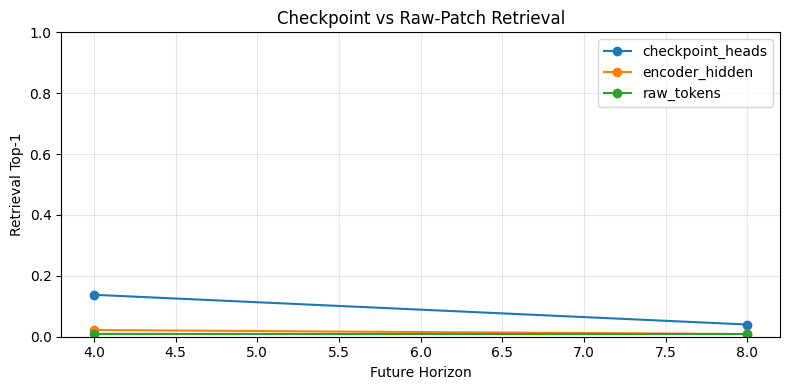

In [32]:
# Optional: compare checkpoint retrieval against raw patch retrieval on the same SSL batches.
# This cell uses ACTIVE_SSL_CHECKPOINT_PATH from the top config / Acquire SSL State cell.
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F

from contrastive_ssl.model import ContrastiveSSLModel

SSL_RETRIEVAL_DIAGNOSTIC_BATCHES = 4
SSL_RETRIEVAL_DIAGNOSTIC_BATCH_SIZE = 16
SSL_RETRIEVAL_DIAGNOSTIC_SPLIT = "val" if CACHE_CONTEXT.has_val_datasets else "train"
SSL_RETRIEVAL_DIAGNOSTIC_CHECKPOINT_PATH = Path(ACTIVE_SSL_CHECKPOINT_PATH)

if not SSL_RETRIEVAL_DIAGNOSTIC_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint path does not exist: {SSL_RETRIEVAL_DIAGNOSTIC_CHECKPOINT_PATH}"
    )

ssl_diag_payload = torch.load(SSL_RETRIEVAL_DIAGNOSTIC_CHECKPOINT_PATH, map_location="cpu")
ssl_diag_config = dict(ssl_diag_payload.get("config", {}))
if not ssl_diag_config:
    ssl_diag_config_path = Path(ACTIVE_SSL_CHECKPOINT_RUN_DIR) / "config.json"
    if ssl_diag_config_path.exists():
        ssl_diag_config = json.loads(ssl_diag_config_path.read_text())

SSL_RETRIEVAL_DIAGNOSTIC_HORIZONS = tuple(
    int(value)
    for value in ssl_diag_config.get(
        "future_horizons",
        config.get("future_horizons", FUTURE_HORIZONS) if isinstance(config, dict) else FUTURE_HORIZONS,
    )
)

ssl_diag_model = ContrastiveSSLModel(
    input_dim=FULL_DIM,
    hidden_size=int(ssl_diag_config["hidden_size"]),
    s5_state_size=int(ssl_diag_config["s5_state_size"]),
    num_layers=int(ssl_diag_config["num_layers"]),
    dropout=float(ssl_diag_config["dropout"]),
    patch_size=int(ssl_diag_config["patch_size"]),
    patch_stride=int(ssl_diag_config["patch_stride"]),
    post_proj_norm=str(ssl_diag_config.get("post_proj_norm", "identity")),
    backbone_direction=str(ssl_diag_config.get("backbone_direction", "causal")),
).to(DEVICE)
ssl_diag_model.load_state_dict(ssl_diag_payload["model_state"])
ssl_diag_model.eval()

ssl_diag_sampler = build_segment_sampler(
    CACHE_CONTEXT,
    SSL_RETRIEVAL_DIAGNOSTIC_SPLIT,
    batch_size=SSL_RETRIEVAL_DIAGNOSTIC_BATCH_SIZE,
    seed=SEED + 404,
    segment_bins=int(ssl_diag_config.get("segment_bins", SEGMENT_BINS)),
    dataset_weight_alpha=float(ssl_diag_config.get("dataset_weight_alpha", DATASET_WEIGHT_ALPHA)),
    examples_per_shard=int(ssl_diag_config.get("examples_per_shard", EXAMPLES_PER_SHARD)),
)


def compute_future_retrieval_rows(anchor_reps, future_reps, token_lengths, horizons, representation_name, batch_index):
    rows = []
    anchor_reps = F.normalize(anchor_reps, dim=-1)
    future_reps = F.normalize(future_reps, dim=-1)

    for horizon in horizons:
        q_list = []
        k_list = []
        local_margins = []
        local_win_flags = []

        for sample_idx, length in enumerate(token_lengths.tolist()):
            usable = int(length) - int(horizon)
            if usable <= 0:
                continue

            q_sample = anchor_reps[sample_idx, :usable]
            k_sample = future_reps[sample_idx, horizon:length]
            q_list.append(q_sample)
            k_list.append(k_sample)

            local_offsets = (-2, -1, 1, 2)
            for time_idx in range(usable):
                true_target = time_idx + int(horizon)
                true_sim = float(torch.dot(anchor_reps[sample_idx, time_idx], future_reps[sample_idx, true_target]).item())
                neighbor_sims = []
                for offset in local_offsets:
                    alt_target = true_target + int(offset)
                    if alt_target < 0 or alt_target >= int(length):
                        continue
                    neighbor_sims.append(
                        float(torch.dot(anchor_reps[sample_idx, time_idx], future_reps[sample_idx, alt_target]).item())
                    )
                if neighbor_sims:
                    best_neighbor = max(neighbor_sims)
                    local_margins.append(true_sim - best_neighbor)
                    local_win_flags.append(float(true_sim > best_neighbor))

        if not q_list:
            continue

        q = torch.cat(q_list, dim=0)
        k = torch.cat(k_list, dim=0)
        logits = q @ k.T
        labels = torch.arange(q.shape[0], device=logits.device)
        rows.append(
            {
                "batch_index": int(batch_index),
                "representation": str(representation_name),
                "horizon": int(horizon),
                "positive_pairs": int(q.shape[0]),
                "candidate_count": int(k.shape[0]),
                "top1": float((logits.argmax(dim=1) == labels).float().mean().item()),
                "loss": float(F.cross_entropy(logits, labels).item()),
                "local_margin_mean": (
                    float(sum(local_margins) / len(local_margins)) if local_margins else None
                ),
                "local_win_rate": (
                    float(sum(local_win_flags) / len(local_win_flags)) if local_win_flags else None
                ),
            }
        )
    return rows


ssl_diag_rows = []
with torch.no_grad():
    for batch_index in range(SSL_RETRIEVAL_DIAGNOSTIC_BATCHES):
        batch = ssl_diag_sampler.sample_batch()
        outputs = ssl_diag_model.encode_sequence(
            batch["x"].to(DEVICE),
            batch["lengths"].to(DEVICE),
        )
        token_lengths = outputs["token_lengths"]
        representation_map = {
            "raw_tokens": (outputs["tokens"], outputs["tokens"]),
            "encoder_hidden": (outputs["hidden"], outputs["hidden"]),
            "checkpoint_heads": (
                ssl_diag_model.anchor_head(outputs["hidden"]),
                ssl_diag_model.future_head(outputs["hidden"]),
            ),
        }
        for representation_name, (anchor_reps, future_reps) in representation_map.items():
            ssl_diag_rows.extend(
                compute_future_retrieval_rows(
                    anchor_reps=anchor_reps,
                    future_reps=future_reps,
                    token_lengths=token_lengths,
                    horizons=SSL_RETRIEVAL_DIAGNOSTIC_HORIZONS,
                    representation_name=representation_name,
                    batch_index=batch_index,
                )
            )

SSL_RETRIEVAL_DIAGNOSTIC_DF = pd.DataFrame(ssl_diag_rows)
SSL_RETRIEVAL_DIAGNOSTIC_SUMMARY = (
    SSL_RETRIEVAL_DIAGNOSTIC_DF.groupby(["representation", "horizon"], as_index=False)
    .agg(
        mean_top1=("top1", "mean"),
        mean_loss=("loss", "mean"),
        mean_local_margin=("local_margin_mean", "mean"),
        mean_local_win_rate=("local_win_rate", "mean"),
        mean_positive_pairs=("positive_pairs", "mean"),
        mean_candidate_count=("candidate_count", "mean"),
    )
    .sort_values(["horizon", "representation"])
    .reset_index(drop=True)
)

display(SSL_RETRIEVAL_DIAGNOSTIC_SUMMARY)
print("SSL_RETRIEVAL_DIAGNOSTIC_CHECKPOINT_PATH:", SSL_RETRIEVAL_DIAGNOSTIC_CHECKPOINT_PATH)
print("SSL_RETRIEVAL_DIAGNOSTIC_SPLIT:", SSL_RETRIEVAL_DIAGNOSTIC_SPLIT)
print("SSL_RETRIEVAL_DIAGNOSTIC_HORIZONS:", SSL_RETRIEVAL_DIAGNOSTIC_HORIZONS)
print(
    "SSL retrieval diagnostic config:",
    {
        "patch_size": ssl_diag_config.get("patch_size"),
        "patch_stride": ssl_diag_config.get("patch_stride"),
        "future_horizons": ssl_diag_config.get("future_horizons"),
        "normalize_impl_version": ssl_diag_config.get("normalize_impl_version"),
    },
)

plt.figure(figsize=(8, 4))
for representation_name, group in SSL_RETRIEVAL_DIAGNOSTIC_SUMMARY.groupby("representation"):
    plt.plot(group["horizon"], group["mean_top1"], marker="o", label=representation_name)
plt.xlabel("Future Horizon")
plt.ylabel("Retrieval Top-1")
plt.title("Checkpoint vs Raw-Patch Retrieval")
plt.ylim(0.0, 1.0)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [31]:
# Shared downstream experiment helpers.
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

FROZEN_LINEAR_PROBE_OVERRIDES = {
    "probe_head_type": "linear",
}

QUICK_CONV1D_PROBE_OVERRIDES = {
    "probe_head_type": "conv1d",
    "probe_conv_hidden_size": DOWNSTREAM_PROBE_DEFAULT_STATE["encoder"].hidden_size,
    "probe_conv_kernel_size": 3,
    "probe_budget_seconds": 120,
    "max_probe_steps": 50,
}

B2_LINEAR_PROBE_OVERRIDES = {
    "probe_head_type": "linear",
    "probe_head_learning_rate": PROBE_HEAD_LEARNING_RATE,
    "encoder_learning_rate": ENCODER_LEARNING_RATE,
    "weight_decay": PROBE_WEIGHT_DECAY,
    "probe_budget_seconds": 600,
    "max_probe_steps": 800,
}

SUMMARY_DISPLAY_COLUMNS = [
    "model_variant",
    "train_encoder",
    "probe_head_type",
    "probe_head_num_parameters",
    "probe_head_learning_rate",
    "encoder_learning_rate",
    "target_session_ids",
    "target_train_examples",
    "target_val_examples",
    "val_ctc_bpphone",
    "val_phoneme_error_rate",
    "most_common_prediction",
    "most_common_prediction_rate",
    "most_common_false_prediction",
    "most_common_false_prediction_rate",
    "top_substitution_pair",
    "probe_steps",
    "probe_elapsed_seconds",
]

COMPARISON_DISPLAY_COLUMNS = [
    "model_variant",
    "train_encoder",
    "probe_head_type",
    "probe_head_learning_rate",
    "encoder_learning_rate",
    "val_ctc_bpphone",
    "val_phoneme_error_rate",
    "most_common_prediction",
    "most_common_prediction_rate",
    "most_common_false_prediction",
    "most_common_false_prediction_rate",
    "top_substitution_pair",
    "probe_steps",
    "probe_elapsed_seconds",
]


def build_notebook_random_probe_state(*, seed_offset: int = 0):
    return build_random_init_probe_state(
        reference_config=DOWNSTREAM_PROBE_DEFAULT_STATE["checkpoint_config"],
        input_dim=FULL_DIM,
        seed=SEED + int(seed_offset),
        base_run_dir=DOWNSTREAM_PROBE_BASE_RUN_DIR,
    )


def run_notebook_probe(
    summary_name: str,
    *,
    probe_state: dict,
    variant_prefix: str,
    artifact_prefix: str,
    train_encoder: bool,
    probe_overrides: dict | None = None,
    comparison_mode: str | None = None,
) -> dict:
    summary = run_downstream_probe(
        probe_state=probe_state,
        probe_config=DOWNSTREAM_PROBE_CONFIG,
        cache_root=CACHE_ROOT,
        device=DEVICE,
        variant_prefix=variant_prefix,
        artifact_prefix=artifact_prefix,
        train_encoder=train_encoder,
        probe_overrides=probe_overrides,
        comparison_mode=comparison_mode,
    )
    globals()[summary_name] = summary
    display(pd.DataFrame([summary])[SUMMARY_DISPLAY_COLUMNS])
    print(f"{summary_name.lower()}_summary_path:", Path(summary["summary_path"]))
    print(f"{summary_name.lower()}_progress_path:", Path(summary["progress_log_path"]))
    if summary.get("alignment_stats_path") is not None:
        print(f"{summary_name.lower()}_alignment_stats_path:", Path(summary["alignment_stats_path"]))
    return summary


def display_probe_comparison(summary_names: list[str], *, columns: list[str] | None = None) -> pd.DataFrame:
    rows = [globals()[name] for name in summary_names if name in globals()]
    if not rows:
        raise ValueError("None of the requested summary variables are defined in the current kernel.")
    frame = pd.DataFrame(rows)
    display(frame[columns or COMPARISON_DISPLAY_COLUMNS])
    return frame


def print_top_items(items, *, max_items: int = 8) -> None:
    if not items:
        print("  <none>")
        return
    for item in items[:max_items]:
        label = item.get("symbol", item.get("id"))
        print(f"  - {label} count={item['count']} rate={item['rate']:.3f}")


def print_substitution_items(items, *, max_items: int = 8) -> None:
    if not items:
        print("  <none>")
        return
    for item in items[:max_items]:
        print(
            f"  - {item['reference_symbol']} -> {item['predicted_symbol']} "
            f"count={item['count']} rate={item['rate']:.3f}"
        )


def print_alignment_diagnostics_from_summary(summary_name: str, *, max_items: int = 8) -> dict:
    if summary_name not in globals():
        raise NameError(f"{summary_name} is not defined in the current kernel.")
    summary = globals()[summary_name]
    stats_path = Path(summary["alignment_stats_path"])
    stats = json.loads(stats_path.read_text())

    print(f"\ndiagnostics_for: {summary_name.lower()}")
    print(" alignment_stats_path:", stats_path)
    print(" total_reference_tokens:", stats["total_reference_tokens"])
    print(" total_predicted_tokens:", stats["total_predicted_tokens"])
    print(" total_edit_distance:", stats["total_edit_distance"])
    print(" total_insertions:", stats["total_insertions"])
    print(" total_deletions:", stats["total_deletions"])
    print(" total_substitutions:", stats["total_substitutions"])

    most_common_prediction = stats.get("most_common_prediction")
    if most_common_prediction is not None:
        print(
            " most_common_prediction:",
            most_common_prediction["symbol"],
            f"count={most_common_prediction['count']} rate={most_common_prediction['rate']:.3f}",
        )

    most_common_false_prediction = stats.get("most_common_false_prediction")
    if most_common_false_prediction is not None:
        print(
            " most_common_false_prediction:",
            most_common_false_prediction["symbol"],
            f"count={most_common_false_prediction['count']} rate={most_common_false_prediction['rate']:.3f}",
        )

    top_substitution_pair = stats.get("top_substitution_pair")
    if top_substitution_pair is not None:
        print(
            " top_substitution_pair:",
            f"{top_substitution_pair['reference_symbol']} -> {top_substitution_pair['predicted_symbol']}",
            f"count={top_substitution_pair['count']} rate={top_substitution_pair['rate']:.3f}",
        )

    print(" prediction_histogram_top:")
    print_top_items(stats.get("prediction_histogram_top", []), max_items=max_items)

    print(" false_prediction_histogram_top:")
    print_top_items(stats.get("false_prediction_histogram_top", []), max_items=max_items)

    print(" insertion_histogram_top:")
    print_top_items(stats.get("insertion_histogram_top", []), max_items=max_items)

    print(" deletion_histogram_top:")
    print_top_items(stats.get("deletion_histogram_top", []), max_items=max_items)

    print(" substitution_histogram_top:")
    print_substitution_items(stats.get("substitution_histogram_top", []), max_items=max_items)
    return stats


def load_probe_progress(summary_name: str) -> pd.DataFrame:
    if summary_name not in globals():
        raise NameError(f"{summary_name} is not defined in the current kernel.")
    progress_path = Path(globals()[summary_name]["progress_log_path"])
    rows = [json.loads(line) for line in progress_path.read_text().splitlines() if line.strip()]
    return pd.DataFrame(rows)


def plot_probe_train_curves(summary_names: list[str]) -> None:
    plt.figure(figsize=(7, 4))
    plotted = False
    for summary_name in summary_names:
        if summary_name not in globals():
            continue
        frame = load_probe_progress(summary_name)
        train_rows = frame[frame["event"] == "probe_train_report"].copy()
        if train_rows.empty:
            continue
        plt.plot(train_rows["step"], train_rows["train_ctc_bpphone"], label=summary_name)
        plotted = True
    if not plotted:
        raise ValueError("None of the requested summaries include probe_train_report rows.")
    plt.xlabel("Probe Step")
    plt.ylabel("Train CTC Bits / Phoneme")
    plt.title("Downstream Probe Train Curves")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


print("FROZEN_LINEAR_PROBE_OVERRIDES:", FROZEN_LINEAR_PROBE_OVERRIDES)
print("QUICK_CONV1D_PROBE_OVERRIDES:", QUICK_CONV1D_PROBE_OVERRIDES)
print("B2_LINEAR_PROBE_OVERRIDES:", B2_LINEAR_PROBE_OVERRIDES)


FROZEN_LINEAR_PROBE_OVERRIDES: {'probe_head_type': 'linear'}
QUICK_CONV1D_PROBE_OVERRIDES: {'probe_head_type': 'conv1d', 'probe_conv_hidden_size': 256, 'probe_conv_kernel_size': 3, 'probe_budget_seconds': 120, 'max_probe_steps': 50}
B2_LINEAR_PROBE_OVERRIDES: {'probe_head_type': 'linear', 'probe_head_learning_rate': 0.001, 'encoder_learning_rate': 0.0001, 'weight_decay': 0.01, 'probe_budget_seconds': 600, 'max_probe_steps': 800}


### Frozen-Encoder Comparisons

These cells keep the encoder frozen.
The two linear cells below are the main apples-to-apples frozen comparison.
The conv1d cell is a quick stronger-head diagnostic with its own smaller budget.


In [33]:
# Frozen SSL checkpoint + linear head.
SSL_PROBE_SUMMARY = run_notebook_probe(
    "SSL_PROBE_SUMMARY",
    probe_state=DOWNSTREAM_PROBE_DEFAULT_STATE,
    variant_prefix="ssl_checkpoint",
    artifact_prefix="ssl_probe_pool4",
    train_encoder=False,
    probe_overrides=FROZEN_LINEAR_PROBE_OVERRIDES,
    comparison_mode="ssl_only_pool4",
)


,model_variant,train_encoder,probe_head_type,probe_head_num_parameters,probe_head_learning_rate,encoder_learning_rate,target_session_ids,target_train_examples,target_val_examples,val_ctc_bpphone,val_phoneme_error_rate,most_common_prediction,most_common_prediction_rate,most_common_false_prediction,most_common_false_prediction_rate,top_substitution_pair,probe_steps,probe_elapsed_seconds
0,ssl_checkpoint_linear_probe,False,linear,10537,0.001,0.0001,"[t15.2025.03.14, t15.2025.03.16, t15.2025.03.3...",394,103,5.666465,0.843241,SIL,0.604683,SIL,0.171429,IY->AW,400,170.61536


ssl_probe_summary_summary_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260411T151117Z/ssl_probe_pool4_linear_probe/downstream_probe_summary.json
ssl_probe_summary_progress_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260411T151117Z/ssl_probe_pool4_linear_probe/progress.jsonl
ssl_probe_summary_alignment_stats_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260411T151117Z/ssl_probe_pool4_linear_probe/val_alignment_stats.json


In [ ]:
# Frozen random-init baseline + linear head.
RANDOM_INIT_LINEAR_PROBE_STATE = build_notebook_random_probe_state()
RANDOM_INIT_LINEAR_PROBE_SUMMARY = run_notebook_probe(
    "RANDOM_INIT_LINEAR_PROBE_SUMMARY",
    probe_state=RANDOM_INIT_LINEAR_PROBE_STATE,
    variant_prefix="random_init",
    artifact_prefix="random_init_pool4",
    train_encoder=False,
    probe_overrides=FROZEN_LINEAR_PROBE_OVERRIDES,
    comparison_mode="random_init_pool4",
)


In [ ]:
# Optional quick stronger-head diagnostic on the frozen SSL encoder.
QUICK_CONV1D_SUMMARY = run_notebook_probe(
    "QUICK_CONV1D_SUMMARY",
    probe_state=DOWNSTREAM_PROBE_DEFAULT_STATE,
    variant_prefix="ssl_checkpoint",
    artifact_prefix="ssl_probe_quick_pool4",
    train_encoder=False,
    probe_overrides=QUICK_CONV1D_PROBE_OVERRIDES,
    comparison_mode="ssl_only_conv1d_pool4_quick",
)


In [34]:
# Compare whichever frozen-probe summaries are currently available.
display_probe_comparison([
    "SSL_PROBE_SUMMARY",
    "RANDOM_INIT_LINEAR_PROBE_SUMMARY",
    "QUICK_CONV1D_SUMMARY",
])


,model_variant,train_encoder,probe_head_type,probe_head_learning_rate,encoder_learning_rate,val_ctc_bpphone,val_phoneme_error_rate,most_common_prediction,most_common_prediction_rate,most_common_false_prediction,most_common_false_prediction_rate,top_substitution_pair,probe_steps,probe_elapsed_seconds
0,ssl_checkpoint_linear_probe,False,linear,0.001,0.0001,5.666465,0.843241,SIL,0.604683,SIL,0.171429,IY->AW,400,170.61536


,model_variant,comparison_mode,probe_head_type,seed,probe_head_num_parameters,probe_head_learning_rate,encoder_learning_rate,weight_decay,train_encoder,adaptation_regime,...,top_substitution_pair,top_substitution_pair_rate,probe_steps,probe_elapsed_seconds,checkpoint_source_used,checkpoint_path,run_dir,progress_log_path,alignment_stats_path,summary_path
0,ssl_checkpoint_linear_probe,ssl_only_pool4,linear,7,10537,0.001,0.0001,0.01,False,A,...,IY->AW,0.021186,400,170.61536,checkpoint,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...


### Full Fine-Tuning Comparisons

These cells run the notebook's simplified `B2` path: fine-tune the encoder and linear head together.
Both cells below use the same shared `B2_LINEAR_PROBE_OVERRIDES` dictionary on purpose.


In [ ]:
# SSL-initialized notebook B2 run.
SSL_B2_SUMMARY = run_notebook_probe(
    "SSL_B2_SUMMARY",
    probe_state=DOWNSTREAM_PROBE_DEFAULT_STATE,
    variant_prefix="ssl_checkpoint_b2",
    artifact_prefix="ssl_probe_b2_pool4",
    train_encoder=True,
    probe_overrides=B2_LINEAR_PROBE_OVERRIDES,
    comparison_mode="ssl_b2_pool4",
)


In [ ]:
# Random-init notebook B2 baseline with the exact same budget as SSL_B2.
RANDOM_INIT_B2_STATE = build_notebook_random_probe_state()
RANDOM_INIT_B2_SUMMARY = run_notebook_probe(
    "RANDOM_INIT_B2_SUMMARY",
    probe_state=RANDOM_INIT_B2_STATE,
    variant_prefix="random_init_b2",
    artifact_prefix="random_init_b2_pool4",
    train_encoder=True,
    probe_overrides=B2_LINEAR_PROBE_OVERRIDES,
    comparison_mode="random_init_b2_pool4",
)


In [36]:
# Compare whichever notebook B2 summaries are currently available.
display_probe_comparison([
    "SSL_B2_SUMMARY",
    "RANDOM_INIT_B2_SUMMARY",
])


ValueError: None of the requested summary variables are defined in the current kernel.

### Diagnostics And Curves

Set the summary names in the cells below to focus on the runs you want to inspect.
The default diagnostic cell targets the notebook `B2` pair because that is the easiest comparison to misread.


In [35]:
# Print compact alignment diagnostics for the summaries listed here.
DIAGNOSTIC_SUMMARY_NAMES = [
    "SSL_B2_SUMMARY",
    "RANDOM_INIT_B2_SUMMARY",
]

display_probe_comparison(DIAGNOSTIC_SUMMARY_NAMES)
for summary_name in DIAGNOSTIC_SUMMARY_NAMES:
    if summary_name in globals():
        print_alignment_diagnostics_from_summary(summary_name)


ValueError: None of the requested summary variables are defined in the current kernel.

In [ ]:
# Plot train curves for any summaries that have progress logs in the current kernel.
PLOT_SUMMARY_NAMES = [
    "SSL_PROBE_SUMMARY",
    "RANDOM_INIT_LINEAR_PROBE_SUMMARY",
    "QUICK_CONV1D_SUMMARY",
    "SSL_B2_SUMMARY",
    "RANDOM_INIT_B2_SUMMARY",
]

plot_probe_train_curves(PLOT_SUMMARY_NAMES)


ValueError: None of the requested summaries include probe_train_report rows.

<Figure size 700x400 with 0 Axes>

## Appendix: One-Time Session-Stats Rebuild

The main notebook flow loads the fixed stable session-stats file from `STABLE_SSL_SESSION_STATS_PATH`.
Only use the maintenance cell below if you intentionally want to recompute the SSL session-level z-scoring stats.


In [ ]:
# Appendix: one-time maintenance cell to rebuild SSL session-level featurewise z-scoring stats.
import random
import time
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch

SESSION_STATS_REFERENCE_DATASET = "000950"
SESSION_STATS_REFERENCE_MULTIPLIER = 2
SESSION_STATS_OUTPUT_DIR = OUTPUT_ROOT / "precomputed_ssl_session_stats"
SESSION_STATS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def stable_text_seed(text: str, base_seed: int) -> int:
    return int(base_seed + sum((idx + 1) * ord(ch) for idx, ch in enumerate(text)))


def session_key_for(dataset: str, session_id: str) -> str:
    return f"{dataset}:{session_id}"


def sample_rows_up_to_bins(rows, *, cap_bins: int, seed: int):
    total_bins = int(sum(int(row.n_time_bins) for row in rows))
    if total_bins <= int(cap_bins):
        return list(rows), total_bins, False

    rng = random.Random(int(seed))
    shuffled = list(rows)
    rng.shuffle(shuffled)

    selected = []
    selected_bins = 0
    for row in shuffled:
        row_bins = int(row.n_time_bins)
        if selected and selected_bins >= int(cap_bins):
            break
        if (selected_bins + row_bins) <= int(cap_bins) or not selected:
            selected.append(row)
            selected_bins += row_bins
    return selected, selected_bins, True


def compute_feature_stats_for_rows(rows):
    sum_x = np.zeros((FULL_DIM,), dtype=np.float64)
    sum_x2 = np.zeros((FULL_DIM,), dtype=np.float64)
    count_x = np.zeros((FULL_DIM,), dtype=np.float64)

    for row in rows:
        shard = SHARD_STORE.get(row.shard_relpath)
        time_offsets = shard["time_offsets"]
        assert isinstance(time_offsets, np.ndarray)
        start = int(time_offsets[row.example_index])
        stop = int(time_offsets[row.example_index + 1])

        tx = shard["tx"]
        if isinstance(tx, np.ndarray):
            tx_window = np.asarray(tx[start:stop], dtype=np.float64)
            tx_dim = min(tx_window.shape[1], TX_DIM)
            sum_x[:tx_dim] += tx_window[:, :tx_dim].sum(axis=0)
            sum_x2[:tx_dim] += np.square(tx_window[:, :tx_dim]).sum(axis=0)
            count_x[:tx_dim] += tx_window.shape[0]

        sbp = shard["sbp"]
        if isinstance(sbp, np.ndarray):
            sbp_window = np.asarray(sbp[start:stop], dtype=np.float64)
            sbp_dim = min(sbp_window.shape[1], SBP_DIM)
            sbp_slice = slice(TX_DIM, TX_DIM + sbp_dim)
            sum_x[sbp_slice] += sbp_window[:, :sbp_dim].sum(axis=0)
            sum_x2[sbp_slice] += np.square(sbp_window[:, :sbp_dim]).sum(axis=0)
            count_x[sbp_slice] += sbp_window.shape[0]

    mean = np.zeros((FULL_DIM,), dtype=np.float32)
    std = np.ones((FULL_DIM,), dtype=np.float32)
    present_mask = count_x > 0
    if present_mask.any():
        mean64 = sum_x[present_mask] / count_x[present_mask]
        var64 = np.maximum(sum_x2[present_mask] / count_x[present_mask] - np.square(mean64), 1e-6)
        mean[present_mask] = mean64.astype(np.float32)
        std[present_mask] = np.sqrt(var64).astype(np.float32)
    return torch.from_numpy(mean), torch.from_numpy(std)


session_rows_by_key = defaultdict(list)
session_order_by_dataset = defaultdict(list)
for dataset in pretrain_datasets:
    seen_session_ids = set()
    for row in CACHE_CONTEXT.rows_by_dataset[dataset]:
        session_rows_by_key[session_key_for(dataset, row.session_id)].append(row)
        if row.session_id not in seen_session_ids:
            session_order_by_dataset[dataset].append(row.session_id)
            seen_session_ids.add(row.session_id)

session_bins_by_key = {
    key: int(sum(int(row.n_time_bins) for row in rows))
    for key, rows in session_rows_by_key.items()
}
reference_session_ids = session_order_by_dataset.get(SESSION_STATS_REFERENCE_DATASET, [])
if not reference_session_ids:
    raise ValueError(
        f"Could not find any pretraining sessions in dataset={SESSION_STATS_REFERENCE_DATASET} to set the sampling cap."
    )

REFERENCE_SESSION_ID = reference_session_ids[0]
REFERENCE_SESSION_KEY = session_key_for(SESSION_STATS_REFERENCE_DATASET, REFERENCE_SESSION_ID)
REFERENCE_SESSION_BINS = int(session_bins_by_key[REFERENCE_SESSION_KEY])
SESSION_STATS_CAP_BINS = int(SESSION_STATS_REFERENCE_MULTIPLIER * REFERENCE_SESSION_BINS)
SSL_SESSION_STATS_PATH = SESSION_STATS_OUTPUT_DIR / (
    f"session_feature_stats_{SOURCE_CACHE_SIGNATURE[:12]}_"
    f"{NORMALIZE_IMPL_VERSION}_refds{SESSION_STATS_REFERENCE_DATASET}_"
    f"cap{SESSION_STATS_CAP_BINS}_tx{TX_DIM}_sbp{SBP_DIM}.pt"
)

print("REFERENCE_DATASET:", SESSION_STATS_REFERENCE_DATASET)
print("REFERENCE_SESSION_ID:", REFERENCE_SESSION_ID)
print("REFERENCE_SESSION_KEY:", REFERENCE_SESSION_KEY)
print("REFERENCE_SESSION_BINS:", REFERENCE_SESSION_BINS)
print("SESSION_STATS_CAP_BINS:", SESSION_STATS_CAP_BINS)
print("SSL_SESSION_STATS_PATH:", SSL_SESSION_STATS_PATH)

if SSL_SESSION_STATS_PATH.exists():
    payload = torch.load(SSL_SESSION_STATS_PATH, map_location="cpu")
    SSL_SESSION_FEATURE_STATS = {
        str(key): (value[0].float().cpu(), value[1].float().cpu())
        for key, value in payload["session_feature_stats"].items()
    }
    SSL_SESSION_STATS_METADATA = dict(payload.get("metadata", {}))
    print("Loaded cached SSL session stats from disk.")
else:
    SSL_SESSION_FEATURE_STATS = {}
    sampling_summary = {}
    total_sessions = len(session_rows_by_key)
    truncated_sessions = 0
    t0 = time.time()

    for session_idx, session_key in enumerate(sorted(session_rows_by_key), start=1):
        rows = session_rows_by_key[session_key]
        sampled_rows, sampled_bins, was_truncated = sample_rows_up_to_bins(
            rows,
            cap_bins=SESSION_STATS_CAP_BINS,
            seed=stable_text_seed(session_key, SEED),
        )
        if was_truncated:
            truncated_sessions += 1
        SSL_SESSION_FEATURE_STATS[session_key] = compute_feature_stats_for_rows(sampled_rows)
        sampling_summary[session_key] = {
            "full_session_bins": int(session_bins_by_key[session_key]),
            "sampled_bins": int(sampled_bins),
            "full_example_count": int(len(rows)),
            "sampled_example_count": int(len(sampled_rows)),
            "truncated": bool(was_truncated),
        }
        if session_idx == 1 or session_idx % 25 == 0 or session_idx == total_sessions:
            print(
                f"session_stats={session_idx}/{total_sessions} key={session_key} "
                f"bins={sampled_bins}/{session_bins_by_key[session_key]} truncated={was_truncated}"
            )

    SSL_SESSION_STATS_METADATA = {
        "source_cache_signature": SOURCE_CACHE_SIGNATURE,
        "normalize_impl_version": NORMALIZE_IMPL_VERSION,
        "reference_dataset": SESSION_STATS_REFERENCE_DATASET,
        "reference_session_id": REFERENCE_SESSION_ID,
        "reference_session_key": REFERENCE_SESSION_KEY,
        "reference_session_bins": int(REFERENCE_SESSION_BINS),
        "session_stats_cap_bins": int(SESSION_STATS_CAP_BINS),
        "session_count": int(len(SSL_SESSION_FEATURE_STATS)),
        "truncated_sessions": int(truncated_sessions),
        "tx_dim": int(TX_DIM),
        "sbp_dim": int(SBP_DIM),
        "seed": int(SEED),
        "cache_root": str(CACHE_ROOT),
        "written_seconds": float(time.time()),
        "sampling_summary": sampling_summary,
    }
    torch.save(
        {
            "metadata": SSL_SESSION_STATS_METADATA,
            "session_feature_stats": SSL_SESSION_FEATURE_STATS,
        },
        SSL_SESSION_STATS_PATH,
    )
    print(f"Saved cached SSL session stats in {time.time() - t0:.1f}s")

CACHE_CONTEXT.session_feature_stats = dict(SSL_SESSION_FEATURE_STATS)
CACHE_CONTEXT.config.normalize_impl_version = NORMALIZE_IMPL_VERSION
CACHE_CONTEXT_NORMALIZE_IMPL_VERSION = CACHE_CONTEXT.normalize_impl_version
SSL_SESSION_STATS_COUNT = len(CACHE_CONTEXT.session_feature_stats)

print("CACHE_CONTEXT_NORMALIZE_IMPL_VERSION (after SSL stats load):", CACHE_CONTEXT_NORMALIZE_IMPL_VERSION)
print("SSL_SESSION_STATS_COUNT:", SSL_SESSION_STATS_COUNT)
print(
    "SSL session stats metadata:",
    {
        "reference_dataset": SSL_SESSION_STATS_METADATA.get("reference_dataset"),
        "reference_session_key": SSL_SESSION_STATS_METADATA.get("reference_session_key"),
        "reference_session_bins": SSL_SESSION_STATS_METADATA.get("reference_session_bins"),
        "session_stats_cap_bins": SSL_SESSION_STATS_METADATA.get("session_stats_cap_bins"),
        "truncated_sessions": SSL_SESSION_STATS_METADATA.get("truncated_sessions"),
    },
)
